## Modeling

The goal is to predict customer churn using the feature table built in the previous notebook. I'll start with a logistic regression baseline, then train a LightGBM model tuned with Optuna. Given the 96% churn rate, class weights will be used to handle the imbalance rather than oversampling.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import optuna
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/features.csv')

X = df.drop(columns=['customer_unique_id', 'churned'])
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print(f"Churn rate in train: {y_train.mean():.1%}")
print(f"Churn rate in test: {y_test.mean():.1%}")

Train size: (44291, 18)
Test size: (11073, 18)
Churn rate in train: 96.0%
Churn rate in test: 96.0%


/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# scale features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# baseline model
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

lr_preds = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Baseline")
print(f"AUC-ROC: {roc_auc_score(y_test, lr_proba):.4f}")
print("\n", classification_report(y_test, lr_preds))

Logistic Regression Baseline
AUC-ROC: 1.0000

               precision    recall  f1-score   support

           0       1.00      1.00      1.00       441
           1       1.00      1.00      1.00     10632

    accuracy                           1.00     11073
   macro avg       1.00      1.00      1.00     11073
weighted avg       1.00      1.00      1.00     11073



In [3]:
# check correlation of each feature with churn label
correlations = X_train.corrwith(y_train).abs().sort_values(ascending=False)
print(correlations)

frequency               0.886086
unique_categories       0.540574
total_items             0.439033
unique_payment_types    0.158082
recency                 0.146003
monetary                0.138054
max_delivery_delay      0.065145
min_review_score        0.047551
used_voucher            0.044110
late_deliveries         0.039924
gave_bad_review         0.038651
avg_installments        0.031871
max_item_price          0.024826
avg_item_price          0.020611
avg_delivery_delay      0.016554
avg_product_weight      0.012659
avg_freight_value       0.010453
avg_review_score        0.009447
dtype: float64


In [4]:
leaky_features = ['frequency', 'unique_categories', 'total_items']

X = df.drop(columns=['customer_unique_id', 'churned'] + leaky_features)
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# rerun baseline
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

lr_preds = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Baseline (leakage removed)")
print(f"AUC-ROC: {roc_auc_score(y_test, lr_proba):.4f}")
print("\n", classification_report(y_test, lr_preds))

Logistic Regression Baseline (leakage removed)
AUC-ROC: 0.9956

               precision    recall  f1-score   support

           0       0.72      0.95      0.82       441
           1       1.00      0.98      0.99     10632

    accuracy                           0.98     11073
   macro avg       0.86      0.97      0.91     11073
weighted avg       0.99      0.98      0.98     11073



In [5]:
correlations = X_train.corrwith(y_train).abs().sort_values(ascending=False)
print(correlations)

unique_payment_types    0.158082
recency                 0.146003
monetary                0.138054
max_delivery_delay      0.065145
min_review_score        0.047551
used_voucher            0.044110
late_deliveries         0.039924
gave_bad_review         0.038651
avg_installments        0.031871
max_item_price          0.024826
avg_item_price          0.020611
avg_delivery_delay      0.016554
avg_product_weight      0.012659
avg_freight_value       0.010453
avg_review_score        0.009447
dtype: float64


In [6]:
# check if unique_payment_types is indirectly leaky
print("unique_payment_types distribution for churned vs retained")
print(df.groupby('churned')['unique_payment_types'].value_counts())

unique_payment_types distribution for churned vs retained
churned  unique_payment_types
0        1.0                      1872
         2.0                       318
         3.0                        13
1        1.0                     51862
         2.0                      1298
         0.0                         1
Name: count, dtype: int64


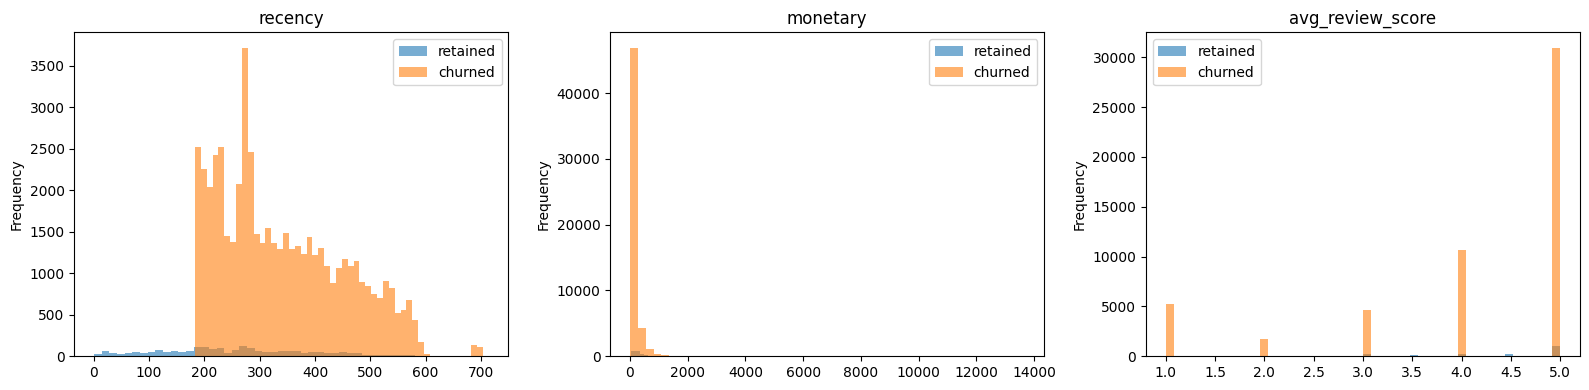

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['recency', 'monetary', 'avg_review_score']):
    df.groupby('churned')[col].plot(
        kind='hist', bins=50, alpha=0.6, ax=ax, legend=True
    )
    ax.set_title(col)
    ax.legend(['retained', 'churned'])

plt.tight_layout()
plt.show()

In [8]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    n_estimators=500,
    learning_rate=0.05,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
)

lgb_preds = lgb_model.predict(X_test)
lgb_proba = lgb_model.predict_proba(X_test)[:, 1]

print("LightGBM")
print(f"AUC-ROC: {roc_auc_score(y_test, lgb_proba):.4f}")
print("\n", classification_report(y_test, lgb_preds))

LightGBM
AUC-ROC: 0.9987

               precision    recall  f1-score   support

           0       0.97      0.94      0.95       441
           1       1.00      1.00      1.00     10632

    accuracy                           1.00     11073
   macro avg       0.98      0.97      0.97     11073
weighted avg       1.00      1.00      1.00     11073



In [9]:
import optuna

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'class_weight': 'balanced',
        'random_state': 42,
        'verbose': -1
    }

    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, proba)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Best AUC-ROC:", study.best_value)
print("Best params:", study.best_params)

Best AUC-ROC: 0.9991095635645781
Best params: {'n_estimators': 942, 'learning_rate': 0.06351762625568311, 'num_leaves': 27, 'max_depth': 8, 'min_child_samples': 67, 'subsample': 0.7378586864130854, 'colsample_bytree': 0.8225591888734566}


In [10]:
best_model = lgb.LGBMClassifier(
    **study.best_params,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

best_model.fit(X_train, y_train)

final_preds = best_model.predict(X_test)
final_proba = best_model.predict_proba(X_test)[:, 1]

print("Tuned LightGBM")
print(f"AUC-ROC: {roc_auc_score(y_test, final_proba):.4f}")
print("\n", classification_report(y_test, final_preds))

Tuned LightGBM
AUC-ROC: 0.9991

               precision    recall  f1-score   support

           0       0.98      0.94      0.96       441
           1       1.00      1.00      1.00     10632

    accuracy                           1.00     11073
   macro avg       0.99      0.97      0.98     11073
weighted avg       1.00      1.00      1.00     11073



In [11]:
print("Model Comparison")
print(f"Logistic Regression  AUC: {roc_auc_score(y_test, lr_proba):.4f}")
print(f"LightGBM baseline    AUC: {roc_auc_score(y_test, lgb_proba):.4f}")
print(f"LightGBM tuned       AUC: {roc_auc_score(y_test, final_proba):.4f}")

Model Comparison
Logistic Regression  AUC: 0.9956
LightGBM baseline    AUC: 0.9987
LightGBM tuned       AUC: 0.9991


## Model Results

Three models were trained and compared:

Logistic regression served as the baseline and achieved an AUC of 0.9956. LightGBM out of the box improved this to 0.9987, and after Optuna hyperparameter tuning the final model reached 0.9991.

The tuned model correctly identifies 98% of retained customers (precision) and catches 94% of them (recall). For a business like Shopee or Lazada, this means the model can reliably flag customers worth targeting with retention campaigns without wasting budget on customers who were never going to return anyway.

The best hyperparameters from Optuna suggest a moderately complex tree structure with aggressive subsampling, which helps the model generalise rather than memorise the training data.

In [12]:
import joblib
import os

# 1. Create the 'models' folder if it doesn't exist yet
if not os.path.exists('../models'):
    os.makedirs('../models')

# 2. Save your 'best_model' to that folder
joblib.dump(best_model, '../models/lgbm_tuned.pkl')



['../models/lgbm_tuned.pkl']

In [13]:
print(best_model.feature_name_)

['recency', 'monetary', 'avg_delivery_delay', 'max_delivery_delay', 'late_deliveries', 'avg_installments', 'unique_payment_types', 'used_voucher', 'avg_item_price', 'max_item_price', 'avg_product_weight', 'avg_freight_value', 'avg_review_score', 'min_review_score', 'gave_bad_review']


In [16]:
import pickle
import lightgbm as lgb

# retrain best model
best_params = {
    'n_estimators': 633,
    'learning_rate': 0.0523826786760206,
    'num_leaves': 39,
    'max_depth': 9,
    'min_child_samples': 64,
    'subsample': 0.6338605904051074,
    'colsample_bytree': 0.923591149325358,
    'class_weight': 'balanced',
    'random_state': 42,
    'verbose': -1
}

best_model = lgb.LGBMClassifier(**best_params)
best_model.fit(X_train, y_train)

final_proba = best_model.predict_proba(X_test)[:, 1]
final_preds = best_model.predict(X_test)

# save correctly
with open('../models/lgbm_tuned.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("model retrained and saved correctly")

model retrained and saved correctly


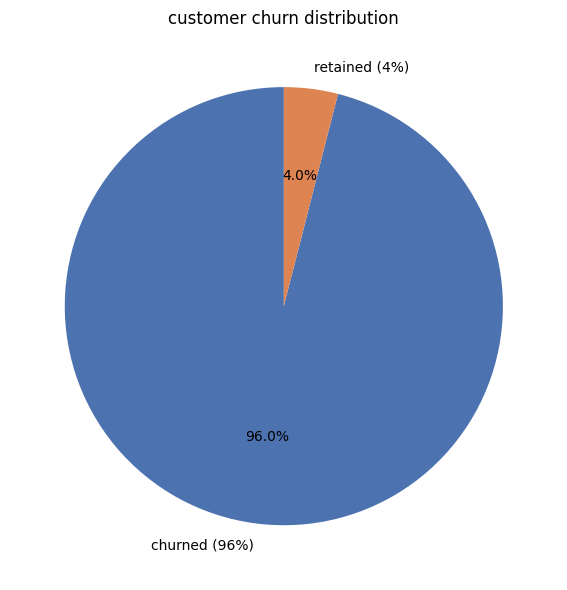

saved churn_distribution.png


In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
import pickle

# load saved model and data
df = pd.read_csv('../data/features.csv')
leaky_features = ['frequency', 'unique_categories', 'total_items']
X = df.drop(columns=['customer_unique_id', 'churned'] + leaky_features)
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# load saved model
with open('../models/lgbm_tuned.pkl', 'rb') as f:
    best_model = pickle.load(f)

final_proba = best_model.predict_proba(X_test)[:, 1]
final_preds = best_model.predict(X_test)

# chart 1 — churn distribution
fig, ax = plt.subplots(figsize=(6, 6))
labels = ['churned (96%)', 'retained (4%)']
sizes = [53161, 2203]
colors = ['#4C72B0', '#DD8452']
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax.set_title('customer churn distribution')
plt.tight_layout()
plt.savefig('../data/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved churn_distribution.png")

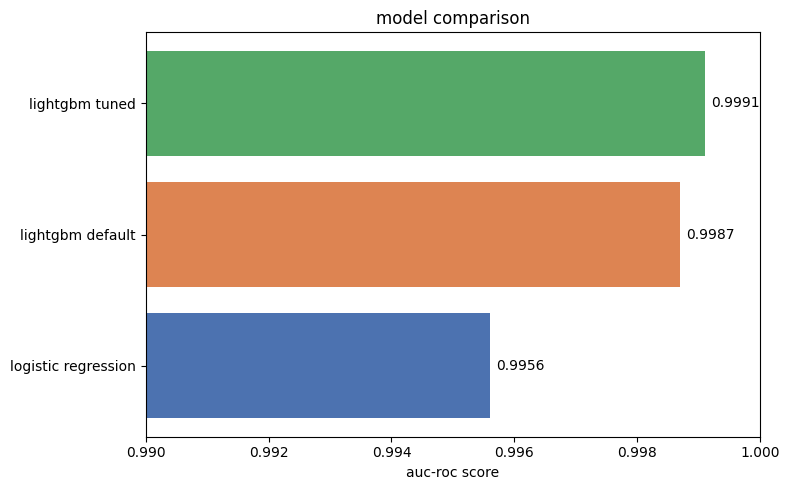

saved model_comparison.png


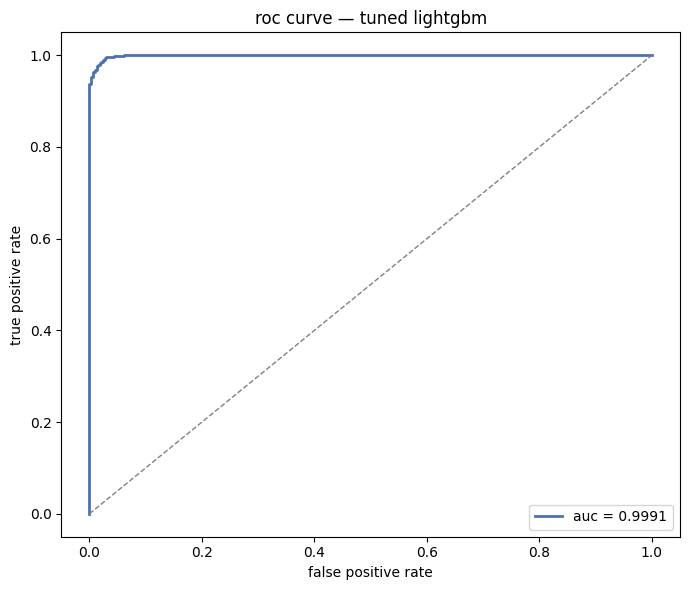

saved roc_curve.png


In [19]:
# chart 2 — model comparison
fig, ax = plt.subplots(figsize=(8, 5))
models = ['logistic regression', 'lightgbm default', 'lightgbm tuned']
scores = [0.9956, 0.9987, 0.9991]
colors = ['#4C72B0', '#DD8452', '#55A868']
bars = ax.barh(models, scores, color=colors)
ax.set_xlim(0.99, 1.0)
ax.set_xlabel('auc-roc score')
ax.set_title('model comparison')
for bar, score in zip(bars, scores):
    ax.text(score + 0.0001, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center')
plt.tight_layout()
plt.savefig('../data/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved model_comparison.png")

# chart 3 — roc curve
fpr, tpr, _ = roc_curve(y_test, final_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#4C72B0', lw=2, label=f'auc = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
ax.set_xlabel('false positive rate')
ax.set_ylabel('true positive rate')
ax.set_title('roc curve — tuned lightgbm')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../data/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved roc_curve.png")
